In [1]:
import pathlib
import pandas as pd
import seaborn as sns
import numpy as np

from matplotlib import pyplot as plt

In [2]:
grid_results_path = pathlib.Path("artifacts/pgexplainer_grid/20260502_124201/MoleculeQDetector")

In [3]:
positive_path = grid_results_path / "positive_explainability_results.csv"
negative_path = grid_results_path / "negative_explainability_results.csv"

positive_df = pd.read_csv(positive_path)

In [4]:
params_to_mean_auroc = {}

epoch_counts = set()
lrs = set()

for column in positive_df.columns[1:]:
    if "auroc" not in column:
        continue

    mean_auroc = positive_df[column].dropna().mean()

    column_fields = column.split("_")
    lr = column_fields[2]
    epochs = column_fields[4]

    epoch_counts.add(epochs)
    lrs.add(lr)

    if lr in params_to_mean_auroc:
        params_to_mean_auroc[lr][epochs] = mean_auroc
    else:
        params_to_mean_auroc[lr] = {epochs: mean_auroc}

for key, value in params_to_mean_auroc.items():
    sorted_list = sorted(value.items(), key=lambda x: int(x[0]))
    sorted_list = [auroc for _, auroc in sorted_list]
    params_to_mean_auroc[key] = sorted_list

sorted_list = [v for _, v in sorted(params_to_mean_auroc.items(), key=lambda item: float(item[0]))]

array = np.array(sorted_list)

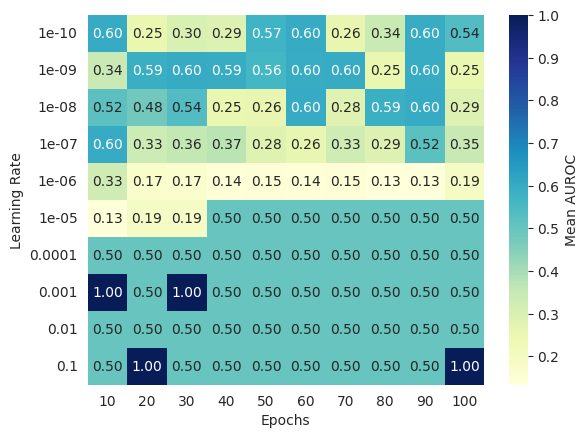

In [5]:
sns.heatmap(array, xticklabels=sorted(epoch_counts, key=lambda x: int(x)),
            yticklabels=sorted(lrs, key=lambda x: float(x)),
            annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Mean AUROC'})

# Set x and y axis labels
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')

plt.savefig("pgexplainer_grid_heatmap.png", dpi=300, bbox_inches='tight')

In [40]:
negative_df = pd.read_csv(negative_path)

params_to_mean_sr = {}

for column in negative_df.columns[1:]:
    success_rate = negative_df[column].dropna().mean()

    column_fields = column.split("_")
    lr = column_fields[2]
    epochs = column_fields[4]

    epoch_counts.add(epochs)
    lrs.add(lr)

    if lr in params_to_mean_sr:
        params_to_mean_sr[lr][epochs] = success_rate
    else:
        params_to_mean_sr[lr] = {epochs: success_rate}

for key, value in params_to_mean_sr.items():
    sorted_list = sorted(value.items(), key=lambda x: int(x[0]))
    sorted_list = [success_rate for _, success_rate in sorted_list]
    params_to_mean_sr[key] = sorted_list

sorted_list = [v for _, v in sorted(params_to_mean_sr.items(), key=lambda item: float(item[0]))]

array = np.array(sorted_list)

<Axes: >

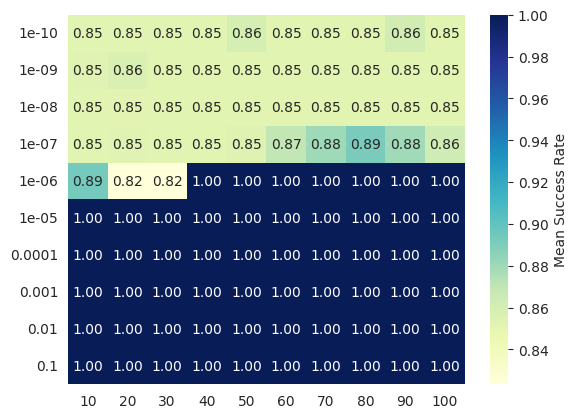

In [41]:
sns.heatmap(array, xticklabels=sorted(epoch_counts, key=lambda x: int(x)),
            yticklabels=sorted(lrs, key=lambda x: float(x)),
            annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Mean Success Rate'})

In [42]:
helios_results = pd.read_csv("plgrid_artifacts/positive_explainability_results.csv")

In [44]:
# Changing to min does not help in any capacity.

for column in helios_results.columns[1:]:
    if "auroc" not in column:
        continue

    mean_auroc = helios_results[column].dropna().mean()
    print(f"{column}: {mean_auroc:.4f}")

PGExplainer_lr_0.1_epochs_10_auroc: 0.5000
PGExplainer_lr_0.1_epochs_20_auroc: 0.5000
PGExplainer_lr_0.1_epochs_30_auroc: 0.5000
PGExplainer_lr_0.1_epochs_40_auroc: 0.5000
PGExplainer_lr_0.1_epochs_50_auroc: 0.5000
PGExplainer_lr_0.1_epochs_60_auroc: 0.5000
PGExplainer_lr_0.1_epochs_70_auroc: 0.5000
PGExplainer_lr_0.1_epochs_80_auroc: 0.5000
PGExplainer_lr_0.1_epochs_90_auroc: 0.5000
